# Deep Calibration: enter a new modelling paradigm via neural models

We exemplify this approach in the case of local stochastic volatility models, some information can also be found in a [talk from Stockholm](https://people.math.ethz.ch/~jteichma/talk_stockholm_2019.pdf). I am grateful to [Florian Krach](https://floriankrach.github.io/) for several improvements on the code.

## Motivation: Calibration of Black Scholes Model



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize

In [ ]:
def compute_black_scholes_price(S, K, T, r, sigma, option_type="call"):
    """
    function to compute the Black-Scholes price for a given option
    :param S: float, the spot price
    :param K: float, the strike price
    :param T: float, the time to maturity
    :param r: float, the risk-free interest rate
    :param sigma: float, the volatility
    :param option_type: str, the option type, either "call" or "put"
    :return: float, the Black-Scholes price
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        return S * stats.norm.cdf(d1) - K * np.exp(-r * T) * stats.norm.cdf(d2)
    elif option_type == "put":
        return K * np.exp(-r * T) * stats.norm.cdf(-d2) - S * stats.norm.cdf(-d1)
    else:
        raise ValueError('option type not supported')

def get_vol_to_price_func(S, K, T, r, option_type="call"):
  return lambda sigma: compute_black_scholes_price(S, K, T, r, sigma, option_type)

let'
s assume some market data:

In [ ]:
S = 1
S1 = 2
K = 1
r = 0
T = 0.5
C_mk = 0.1
C_mk1 = 1.05

C = get_vol_to_price_func(S, K, T, r)
C1 = get_vol_to_price_func(S1, K, T, r)

sigmas = np.linspace(0, 2, 1000)[1:]
imp_vols = [C(sig) for sig in sigmas]
imp_vols1 = [C1(sig) for sig in sigmas]


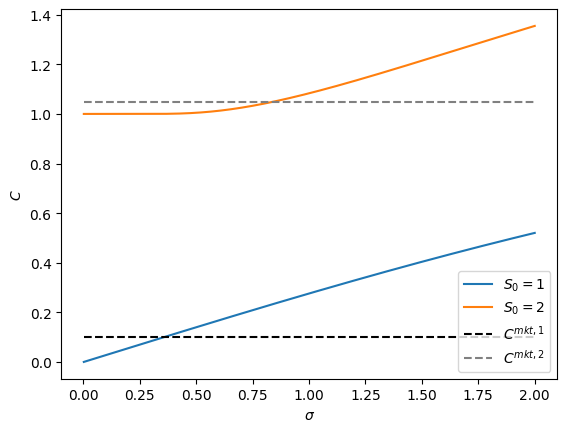

In [ ]:
plt.plot(sigmas, imp_vols, label="$S_0=1$")
plt.plot(sigmas, imp_vols1, label="$S_0=2$")
plt.hlines(y=C_mk, ls="--", color="black", xmin=np.min(sigmas), xmax=np.max(sigmas), label="$C^{mkt, 1}$")
plt.hlines(y=C_mk1, ls="--", color="grey", xmin=np.min(sigmas), xmax=np.max(sigmas), label="$C^{mkt, 2}$")
plt.xlabel("$\sigma$")
plt.ylabel("$C$")
plt.legend()
plt.show()


In the out-of-the-money option, i.e., for $S_0=2$ (orange curve) we see that the price is nearly constant for $\sigma \in [0,0.5]$, hence calibrating the model for a price close to $1$ (corresponding to a standard market scenario) is hard!

let's find the implied volatilities:

In [ ]:
res = minimize(lambda sig: (C_mk - C(sig))**2, x0=.1)
res1 = minimize(lambda sig: (C_mk1 - C1(sig))**2, x0=1.)
imp_vol = res.x[0]
imp_vol1 = res1.x[0]
print("BS implied volatility for C_1:", imp_vol)
print("BS implied volatility for C_2:", imp_vol1)

BS implied volatility for C_1: 0.3554167631553045
BS implied volatility for C_2: 0.8454251011630973


We see that they are different for the 2 options.

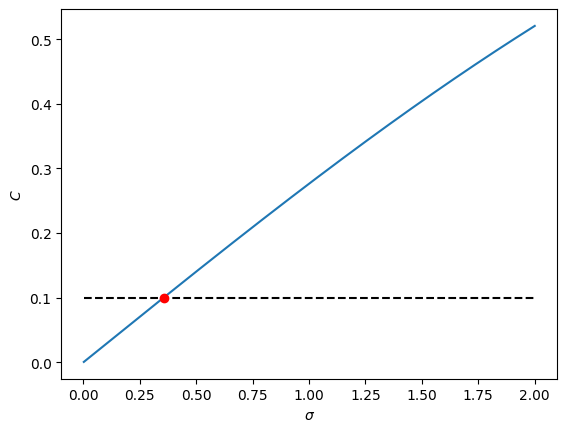

In [ ]:
plt.plot(sigmas, imp_vols)
plt.hlines(y=C_mk, ls="--", color="black", xmin=np.min(sigmas), xmax=np.max(sigmas))
plt.plot(imp_vol, C_mk, color="red", marker="o")
plt.xlabel("$\sigma$")
plt.ylabel("$C$")
plt.show()

## Local volatility models

BS can be fit only to one call price. To fit to the surface of all call prices simultaneously, we introduce models with more flexibility.

Local stochastic volatility models are an extension of local volatility models, which considerably improve their econometric and dynamic properties.

A local volatility model is a model of the type
$$
d S_t = \sigma(t,S_t) S_t dW_t
$$
for some initial price $S_0$ and some \emph{local volatility function} $ (t,S) \mapsto \sigma(t,S) $. It goes back to Bruno Dupire's groundbreaking article [Pricing with a smile](https://web.archive.org/web/20120907114056/http://www.risk.net/data/risk/pdf/technical/2007/risk20_0707_technical_volatility.pdf), where essentially the [Breeden-Litzenberger formula](http://efinance.org.cn/cn/fe/Prices%20of%20State-Contingent%20Claims%20Implicit%20in%20Option%20Prices.pdf) is used. This formula asserts that
$$
\partial^2_K C(T,K) dK = p_T(K) dK = \mathrm{law}(S_T)(dK)
$$
for European option prices $ C(T,K) $ in an interest-rate free market environment: in other words one can calculate the risk-neutral density of the price process from option prices.

The derivation is -- besides technical details -- easy: the Fokker-Planck equation, which is an equation in the forward variable (and not in $S_0$!), asserts that
$$
\partial_T p_T(S) = \frac{1}{2} \partial_S^2 (S^2 \sigma^2(T,S) p_T(S))
$$
holds true. Consider now the pairing of this equation with $ (. - K)_+ $, then it reads
$$
\partial_T C(T,K) = \frac{1}{2} \int \partial_S^2 \big( S^2 \sigma(T,S) p_T(S) \big) (S-K)_+ dS \, .
$$
Applying twice integration by parts leads via the Breeden-Litzenberger formula to
$$
\partial_T C(T,K) = \frac{1}{2} \int S^2 \sigma^2(T,S) p_T(S) \delta_K(dS) = \frac{1}{2}\sigma^2(T,K) K^2 \partial_K^2 C(T,K) \, .
$$
The Dupire formula for local volatility
$$
\sigma^2_{\text{Dupire}}(T,K) = \frac{2 \partial_T C(T,K)}{K^2 \partial_K^2 C(T,K)}
$$
therefore yields a local volatility model which produces precisely the prices $C(T,K)$ for European options with maturity $ T $ and strike price $ K $.

**Note**: In reality we do not have a smooth function $C$ but only finitley many prices, which need to be interpolated smootlhy (not always easy to do!).


## Local stochastic volatility models

Now we have to answer a second question: imagine that we have a local volatility model
$$
d \tilde S_t = \tilde S_t \sigma_{\text{Dupire}}(t,\tilde S_t) dW_t
$$
and a second model, a so called local stochastic volatility model with leverage function $l$ and some exogenous process $ \alpha $ given on the same stochastic basis
$$
dS_t = S_t \alpha_t l(t,S_t) dW_t
$$
and with initial value $ S_0 $ each. When do both models have the same marginal distributions for every time $ T \geq 0 $, in other words, when do the prices of European call options coincide? This is clearly the case when both models behave stochastically at each point in time the same, which is the case when the conditional variances at any point $S_T$ for each $ T \geq 0 $ coincide, i.e.
$$
E \big[ \alpha_t^2 l^2(t,S_t) S_t^2 | S_t = x \big] = l^2(T,x) x^2 E \big[ \alpha_t^2 | S_t = x \big] = \sigma_{\text{Dupire}}^2(t,x) x^2 \, .
$$
Therefore the analogue to Dupire's formula in the case of local stochastic volatility models is
$$
d S_t = S_t \alpha_t \frac{\sigma_{\text{Dupire}}(t,S_t)}{\sqrt{E[\alpha^2_t | S_t = x]|_{x=S_t}}} d W_t \, .
$$
This is the McKean-Vlasov-version of the local stochastic volatility model of Pierre Henry-Labordere paper [Calibration of local stochastic volatility models to Market smiles: a Monte-Carlo approach](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1493306).


## Local stochastic volatility model via neural SDE & deep hedging variance reduction


We take a different road here and do not derive particle methods to solve the McKean-Vlasov equation but rather parametrize the leverage function $l$ by neural networks. This corresponds to writing directly neural network models and learning them to fulfill tasks.

We can set up the problem to infer the local volatility function $ l $ from derivativess' prices in the following machine learning fashion: try to find a function $ l $, given via neural networks and hedges $ H^{(K,T)} $ such that
$$
\sum_{(K,T)} {\Big[E\big[(S_T-K)_+ - C_{\text{market}}(K,T) - (H^{(K,T)}\bullet S)_T \big]\Big]}^2 \rightarrow \text{min!} \, .
$$
Notice that the sum is running over a finite set of price data points. The hedges, also given by neural networks, are improved according to
$$
\sum_{(K,T)} E\big[{((S_T-K)_+ - C_{\text{market}}(K,T) - (H^{(K,T)}\bullet S)_T )}^2 \big] \rightarrow \text{min!} \, .
$$
Notice the difference in the place of the expectation. The problem can possibly solve the calibration problem but one has to learn the leverage function and the hedges simultanously with respect to \emph{different} loss functions.

Let us see in the sequel if this can work out. We shall use notation which reminds the above formulation.

In [ ]:
#%tensorflow_version 1.x
!pip install tensorflow==2.12.0
import tensorflow as tf

#import tensorflow.compat.v1 as tf
#tf.disable_v2_behavior()

import numpy as np
#import tensorflow as tf

from keras.models import Sequential
from keras.layers import Input, Dense, Conv2D, Concatenate, Dropout, Subtract, \
                        Flatten, MaxPooling2D, Multiply, Lambda, Add, Dot
#from keras.backend import constant
from keras import optimizers

from keras.models import Model
from keras.layers import Input
from keras import initializers
from keras.constraints import max_norm
import keras.backend as K

First we create two identical models where either only hedges or local volatilities can be trained.

In [ ]:
# set seed for reproducibility

import keras
keras.utils.set_random_seed(345)

In [ ]:
m = 10 # layer dimension
n = 2 # number of layers for local volatility
N = 20 # time discretization (should fit to maturities), i.e., each maturity should be a multiple of T/N
maturities = [0.5, 1.] # list of maturities in years

T = 1.0

use_same_hedge_network_all_options = False #True  # whether to use one NN for hedging of all options or different ones

layers = []
for j in range(len(maturities)):
    layersatT = []
    for i in range(n):
        if i < n-1:
            nodes = m
        else:
            nodes = 1
        layer = Dense(nodes, activation='relu', trainable=False,  # localvol layers are not trainable
                      kernel_initializer=initializers.RandomNormal(0, 1),#kernel_initializer='random_normal',
                      bias_initializer='random_normal')
        layersatT = layersatT + [layer]
    layers = layers + [layersatT]

#P = {(1.0,1.0): 0.4, (1.1,1.0):0.2, (0.9,1.0):0.5,
#     (1.0,0.5): 0.2, (1.1,0.5):0.1, (0.9,0.5):0.3}

# the options of the market, given in the form: (strike, maturity): price
P = {(0.9, 0.5): 0.20042534,
    (0.9, 1.0): 0.23559685,
    (1.0, 0.5): 0.16312157,
    (1.0, 1.0): 0.20771958,
    (1.1, 0.5): 0.13154241,
    (1.1, 1.0): 0.18236567}

hedges = {}
for key in P.keys():
    hedgeskey =[]
    for j in range(N):  # for each option and each discritization step a different NN for the hedging strategy
        nodes=1
        hedge = Dense(nodes, activation='relu', trainable=True,  # hedges are trainable
                      kernel_initializer=initializers.RandomNormal(0,0.1),#kernel_initializer='random_normal',
                      bias_initializer='random_normal')
        hedgeskey = hedgeskey + [hedge]
    hedges[key] = hedgeskey


In [ ]:
keylist = list(P.keys())
price = Input(shape=(1,))
hedgepf = [Input(shape=(1,)) for l in range(len(P.keys()))]
inputs = [price] + hedgepf
inputshelper = []
hedgeratio = {}
hedge = {}
pricekey = [0 for l in range(len(P.keys()))]

normal = tf.compat.v1.distributions.Normal(loc=0., scale=1.)

def BS(x):
    """
    the Black Scholes Delta Hedge

    key[0]: strike of option
    key[1]: maturity of option
    j: current time step
    """
    price=x[0]
    vola=x[1]
    return normal.cdf((K.log(K.abs(price)/key[0])+0.5*(key[1]-j*T/N)*vola**2)/(0.00001+np.sqrt(key[1]-j*T/N)*vola))
# increases computational time

i = 0  # index of current maturity
for j in range(0,N):  # loop over discrete time steps
    #i=0
    if maturities[i] < j*T/N:  # increase maturity index if time passed the current maturity
        i+=1
    helper0 = layers[i][0](price)  # use localvol NN for maturity i and aggregate all layers
    for k in range(1,n):
        helper0 = layers[i][k](helper0) # localvol applied to price at time j*T/N
    BMincr = Input(shape=(1,)) # stand. normal sample, corresponds to scaled BM increment
    stochvol = Input(shape=(1,)) # stochvol value (alpha)
    helper1 = Multiply()([helper0,BMincr])  # NN_localvol * Normal
    helper1 = Lambda(lambda x: x * np.sqrt(T/N))(helper1)  # NN_localvol * Delta W; (multiply by sqrt(Delta t) to get BM incr)
    priceincr = Multiply()([helper1,stochvol]) # new price increment Delta S; NN_localvol * alpha * Delta W
    for l in range(len(P.keys())):  # go through all options
        key = keylist[l]
        if use_same_hedge_network_all_options:
          hedgeratio[key] = hedges[keylist[0]][j](price)
        else:
          hedgeratio[key] = hedges[key][j](price)  # NN_hedge_strategy takes current price as input and uses the hedging NN specific for the option and the time step
        BSstrategy = Lambda(BS)([price,Multiply()([helper0,stochvol])])  # BS delta hedge strategy applied for current price and vol
        hedgeratio[key] = Add()([hedgeratio[key],BSstrategy])  # use as hedging strategy the BS_strategy + NN_hedge_strategy
        hedge[key] = Multiply()([priceincr,hedgeratio[key]])  # increment of stochastic integral for hedge
        hedgepf[l] = Add()([hedgepf[l],hedge[key]])  # current value of stoch integral for hedge
        if key[1]==((j+1)*T/N): # the option expires
            helper2 = Lambda(lambda x : 0.5*(abs(x-key[0])+x-key[0]))(Add()([price,priceincr]))  # lambda equals max(price - K, 0), use the price at j+1 as input (price+priceincr)
            helper2 = Subtract()([helper2,hedgepf[l]]) # payoff minus hedge
            pricekey[l] = helper2  # model output
    price = Add()([price,priceincr]) # new price after one time step
    inputshelper = inputshelper + [stochvol]
    inputs = inputs + [BMincr]

inputs = inputs + inputshelper  # help to sort the inputs (first all BMincr then all stochvol)
pricekey = Concatenate()(pricekey)
localvol_trainhedge = Model(inputs=inputs, outputs=pricekey)

<ipython-input-80-b60f1aca8953>:22: RuntimeWarning: invalid value encountered in sqrt
  return normal.cdf((K.log(K.abs(price)/key[0])+0.5*(key[1]-j*T/N)*vola**2)/(0.00001+np.sqrt(key[1]-j*T/N)*vola))


Pay attention here: don't jump back and forth when defining models since layer lists come with the same names, so the order of execution is important!

In [ ]:
layers = []

for j in range(len(maturities)):
    layersatT = []
    for i in range(2):
        if i < 1:
            nodes = m
        else:
            nodes = 1
        layer = Dense(nodes, activation='relu', trainable=True,  # localvol trainable
                      kernel_initializer=initializers.RandomNormal(0, 1),#kernel_initializer='random_normal',
                      bias_initializer='random_normal')
        layersatT = layersatT + [layer]
    layers = layers + [layersatT]


hedges = {}
for key in P.keys():
    hedgeskey =[]
    for j in range(N):
        nodes = 1
        hedge = Dense(nodes, activation='relu', trainable=False,  # hedges not trainable
                      kernel_initializer=initializers.RandomNormal(0,0.1),#kernel_initializer='random_normal',
                      bias_initializer='random_normal')
        hedgeskey = hedgeskey + [hedge]
    hedges[key] = hedgeskey
start = 0

In [ ]:
keylist = list(P.keys())
price = Input(shape=(1,))
hedgepf = [Input(shape=(1,)) for l in range(len(P.keys()))]
inputs = [price] + hedgepf
inputshelper = []
hedgeratio = {}
hedge = {}
pricekey = [0 for l in range(len(P.keys()))]

i = 0  # index of current maturity
for j in range(0,N):  # loop over discrete time steps
    #i=0
    if maturities[i] < j*T/N:  # increase maturity index if time passed the current maturity
        i+=1
    helper0 = layers[i][0](price)  # use localvol NN for maturity i and aggregate all layers
    for k in range(1,n):
        helper0 = layers[i][k](helper0) # localvol applied to price at time j*T/N
    BMincr = Input(shape=(1,)) # stand. normal sample, corresponds to scaled BM increment
    stochvol = Input(shape=(1,)) # stochvol value (alpha)
    helper1 = Multiply()([helper0,BMincr])  # NN_localvol * Normal
    helper1 = Lambda(lambda x: x * np.sqrt(T/N))(helper1)  # NN_localvol * Delta W; (multiply by sqrt(Delta t) to get BM incr)
    priceincr = Multiply()([helper1,stochvol]) # new price increment Delta S; NN_localvol * alpha * Delta W
    for l in range(len(P.keys())):  # go through all options
        key = keylist[l]
        if use_same_hedge_network_all_options:
          hedgeratio[key] = hedges[keylist[0]][j](price)
        else:
          hedgeratio[key] = hedges[key][j](price)  # NN_hedge_strategy takes current price as input and uses the hedging NN specific for the option and the time step
        BSstrategy = Lambda(BS)([price,Multiply()([helper0,stochvol])])  # BS delta hedge strategy applied for current price and vol
        hedgeratio[key] = Add()([hedgeratio[key],BSstrategy])  # use as hedging strategy the BS_strategy + NN_hedge_strategy
        hedge[key] = Multiply()([priceincr,hedgeratio[key]])  # increment of stochastic integral for hedge
        hedgepf[l] = Add()([hedgepf[l],hedge[key]])  # current value of stoch integral for hedge
        if key[1]==((j+1)*T/N): # the option expires
            helper2 = Lambda(lambda x : 0.5*(abs(x-key[0])+x-key[0]))(Add()([price,priceincr]))  # lambda equals max(price - K, 0), use the price at j+1 as input (price+priceincr)
            helper2 = Subtract()([helper2,hedgepf[l]]) # payoff minus hedge
            pricekey[l] = helper2  # model output
    price = Add()([price,priceincr]) # new price after one time step
    inputshelper = inputshelper + [stochvol]
    inputs = inputs + [BMincr]

inputs = inputs + inputshelper  # help to sort the inputs (first all BMincr then all stochvol)
pricekey = Concatenate()(pricekey)
localvol_trainlocvol = Model(inputs=inputs, outputs=pricekey)

<ipython-input-80-b60f1aca8953>:22: RuntimeWarning: invalid value encountered in sqrt
  return normal.cdf((K.log(K.abs(price)/key[0])+0.5*(key[1]-j*T/N)*vola**2)/(0.00001+np.sqrt(key[1]-j*T/N)*vola))


In [ ]:
#localvol_trainhedge.summary()

Here we use a very small amount of trajectories due to the variance reduction coming from hedges just for purposes of illustration even though it already works relatively well. Below we consecutively train hedges or local volatilities.

In [ ]:
Ltrain = 5*10**3

# xtrain are the inputs needed for the model; used inputs listed below:
#   S_0=1; Stoch. Integral start value for each option =0;
#   Normal RV (scaled BM incr) for each timestep of discretization = sampled from stand normal;
#   alpha (exogenous volatility process) values for each timestep = 1
xtrain = ([np.ones(Ltrain)] + [np.zeros(Ltrain) for key in keylist]+
          [np.random.normal(0,1,Ltrain) for i in range(N)]+
          [np.ones(Ltrain) for i in range(N)])

# ytrain are the target values for the model output, given by the market prices of the options (repeated for each iid training sample)
ytrain = np.array(list(P.values())).reshape((1,-1)).repeat(Ltrain, axis=0)

In [ ]:
# custom loss function for the localvol network

def localvol_loss_fn(y_true, y_pred):
    return K.mean(K.square(K.mean(y_pred, axis=0) - K.mean(y_true, axis=0)))  # Note that `axis=0` takes mean over samples of the batch


In the sequel the actual training is performed:

In [ ]:
import matplotlib.pyplot as plt

localvol_trainhedge.compile(optimizer='adam',
              loss='mean_squared_error')
localvol_trainlocvol.compile(optimizer='adam',
              loss=localvol_loss_fn)

Epoch 1/10
157/157 [==============================] - 56s 21ms/step - loss: 0.0108
Epoch 2/10
157/157 [==============================] - 3s 16ms/step - loss: 0.0108
Epoch 3/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0108
Epoch 4/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0108
Epoch 5/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0108
Epoch 6/10
157/157 [==============================] - 3s 22ms/step - loss: 0.0108
Epoch 7/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0108
Epoch 8/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0108
Epoch 9/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0108
Epoch 10/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0108
Epoch 1/15
1/1 [==============================] - 28s 28s/step - loss: 9.3801e-04
Epoch 2/15
1/1 [==============================] - 0s 64ms/step - loss: 9.1380e-04
Epoch 3/15
1/1

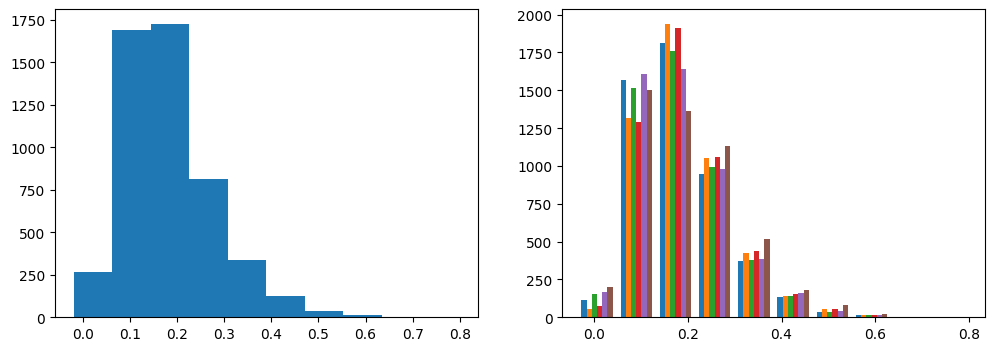

model values:  [0.18286136, 0.19472332, 0.18390201, 0.19533879, 0.18351112, 0.1947695]
target values: [0.20042534, 0.23559685, 0.16312157, 0.20771958, 0.13154241, 0.18236567]
Epoch 1/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0105
Epoch 2/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0105
Epoch 3/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0105
Epoch 4/10
157/157 [==============================] - 3s 17ms/step - loss: 0.0104
Epoch 5/10
157/157 [==============================] - 3s 19ms/step - loss: 0.0104
Epoch 6/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0104
Epoch 7/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0104
Epoch 8/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0104
Epoch 9/10
157/157 [==============================] - 3s 20ms/step - loss: 0.0104
Epoch 10/10
157/157 [==============================] - 3s 17ms/step - loss: 0.0104
Epoc

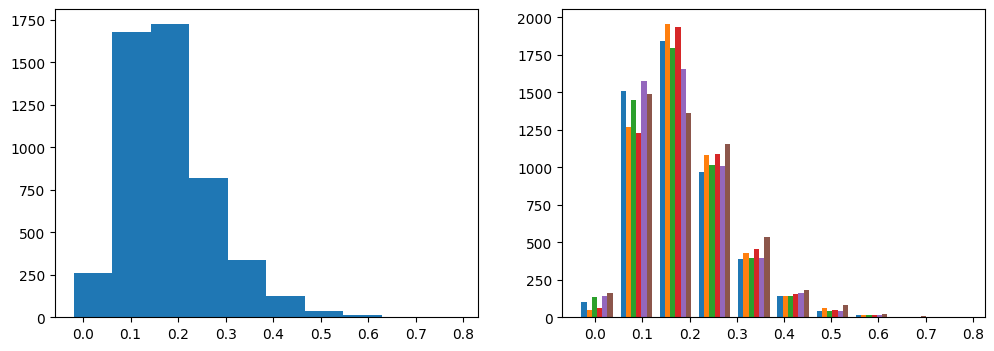

model values:  [0.18120588, 0.19300269, 0.18225108, 0.19361955, 0.18185753, 0.19304107]
target values: [0.20042534, 0.23559685, 0.16312157, 0.20771958, 0.13154241, 0.18236567]
Epoch 1/10
157/157 [==============================] - 4s 22ms/step - loss: 0.0103
Epoch 2/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0103
Epoch 3/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0103
Epoch 4/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0103
Epoch 5/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0103
Epoch 6/10
157/157 [==============================] - 3s 22ms/step - loss: 0.0103
Epoch 7/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0103
Epoch 8/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0103
Epoch 9/10
157/157 [==============================] - 2s 15ms/step - loss: 0.0103
Epoch 10/10
157/157 [==============================] - 2s 16ms/step - loss: 0.0103
Epo

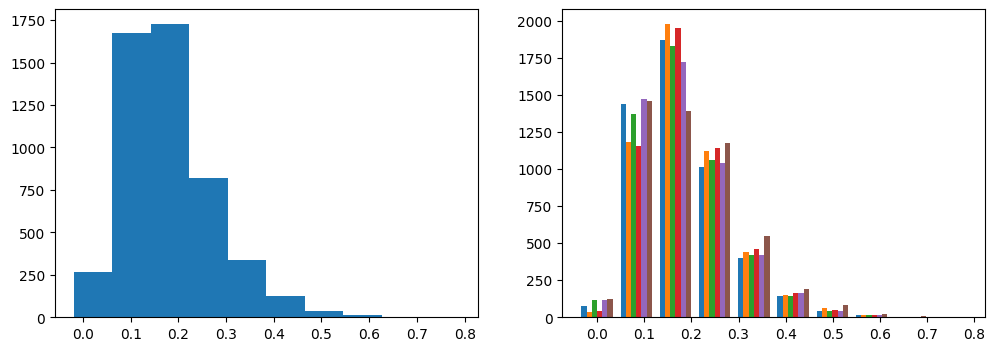

model values:  [0.1807412, 0.19253963, 0.1818113, 0.19315697, 0.18140726, 0.19256042]
target values: [0.20042534, 0.23559685, 0.16312157, 0.20771958, 0.13154241, 0.18236567]


In [ ]:
for k in range(3):
    localvol_trainhedge.fit(x=xtrain,y=ytrain, epochs=10, verbose=True)  # batch_size=32 (default value)
    x = localvol_trainhedge.get_weights()
    localvol_trainlocvol.set_weights(x)
    localvol_trainlocvol.fit(x=xtrain,y=ytrain, epochs=15,verbose=True, batch_size=Ltrain)  # batch_size=10**3 (for localvol we need many samples to approximate the expectation well)
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    predictions = localvol_trainlocvol.predict(xtrain)
    axs[0].hist(predictions[:,0])  # plot distribution of first model option price
    axs[1].hist(predictions[:,:])  # plot distribution of all model option prices
    plt.show()
    print("model values: ", list(np.mean(predictions, axis=0)))
    print("target values:", list(P.values()))
    y = localvol_trainlocvol.get_weights()
    localvol_trainhedge.set_weights(y)

Hedging helps to reduce variance tremendously, and therefore makes the classical means square calibration approach work with batches of only $1000$ samples (i.e., only $1000$ MC samples to approximate the expectation)

Now we can evaluate the calibrated model using 1M paths

In [ ]:
Ltest = 10**6

xtest = ([np.ones(Ltest)] + [np.zeros(Ltest) for key in keylist]+
         [np.random.normal(0,1,Ltest) for i in range(N)]+
         [np.ones(Ltest) for i in range(N)])

ytest = np.array(list(P.values())).reshape((1,-1)).repeat(Ltest, axis=0)

In [ ]:
predictions = localvol_trainlocvol.predict(xtest)

31250/31250 [==============================] - 208s 7ms/step


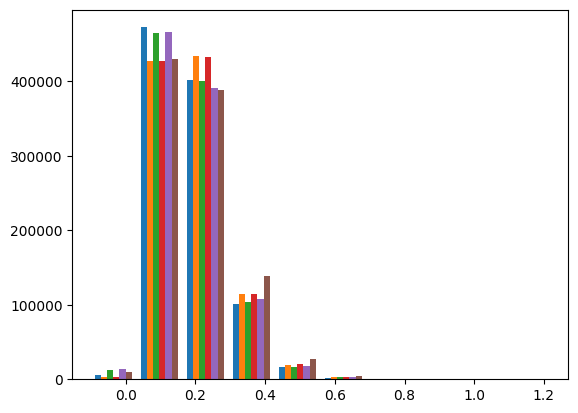

Calibrated values: [0.18268839, 0.19332032, 0.18275593, 0.19342335, 0.18273543, 0.19340144]
Ground truth:      [0.20042534, 0.23559685, 0.16312157, 0.20771958, 0.13154241, 0.18236567]


In [ ]:
plt.hist(predictions[:,:])
plt.show()
print('Calibrated values:', list(np.mean(predictions, axis=0)))
print('Ground truth:     ', list(P.values()))

In [ ]:
P

{(0.9, 0.5): 0.20042534,
 (0.9, 1.0): 0.23559685,
 (1.0, 0.5): 0.16312157,
 (1.0, 1.0): 0.20771958,
 (1.1, 0.5): 0.13154241,
 (1.1, 1.0): 0.18236567}

... not so bad.

In [ ]:
#maturities = [0.1, 0.25, 0.5, 1.0]
#strikes = [0.8, 0.9, 1.0, 1.1, 1.2]
#for T in maturities:
#    for K in strikes:
#         P[(K,T)] = 1.0
#Lgen = 10**6
#keylist = P.keys()
#xgen =([np.ones(Lgen)] + [np.zeros(Lgen) for key in keylist]+
#       [np.random.normal(0,1,Lgen) for i in range(N)]+
#       [np.ones(Lgen) for i in range(N)])
#
#ygen=np.mean(localvol_trainlocvol.predict(xgen)[:,:],axis=0)
#for l in range(len(P.keys())):
#    key = keylist[l]
#    P[key] = ygen[1,l]